In [1]:
import os
import re
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
with open("Star_Configurations/current_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Example access:
print(cfg["main_star"])

V* RV UMa


In [3]:
base_dir = Path(cfg["base_dir"])
print("base_dir = "+str(base_dir))

file_object = cfg["file_object"]
print("file_object = "+str(file_object))

main_star = cfg["main_star"]
print("main_star = "+main_star)

file_nights = cfg["file_nights"].keys()
file_nights = list(file_nights)
print("file_nights = "+str(file_nights))

base_dir = data
file_object = RV_UMa
main_star = V* RV UMa
file_nights = ['2022_03_20', '2022_03_22', '2022_03_24', '2023_02_23', '2023_04_03', '2023_04_19']


In [4]:
night = file_nights[2]
print(night)

colour_list = cfg['file_nights'][str(night)]["colour_list"]
threshold_for_DAO = cfg['file_nights'][str(night)]["threshold_for_DAO"]

print(colour_list)
print(threshold_for_DAO)

2022_03_24
['Luminance', 'Red', 'Green', 'Blue']
4.5


In [5]:
# Prepare a list to store results
results = []

# Loop through colours and files
for colour in colour_list:
    folder = base_dir / file_object / night / "Light" / colour / "photometry"
    for file in os.listdir(folder):
        if file.endswith(".csv"):
            file_path = folder / file
            with open(file_path, "r") as f:
                row_count = sum(1 for line in f) - 1  # subtract header
            print(f"Number of stars detected in {file}: {row_count}")
            results.append({
                "filename": file,
                "colour": colour,
                "number_of_stars": row_count
            })

# Convert to DataFrame and save as CSV
results_df = pd.DataFrame(results)

Number of stars detected in RV_Uma_Light_Luminance_16_secs_001_reduced_photometry.csv: 46
Number of stars detected in RV_Uma_Light_Luminance_16_secs_002_reduced_photometry.csv: 49
Number of stars detected in RV_Uma_Light_Luminance_16_secs_003_reduced_photometry.csv: 42
Number of stars detected in RV_Uma_Light_Luminance_16_secs_004_reduced_photometry.csv: 43
Number of stars detected in RV_Uma_Light_Luminance_16_secs_005_reduced_photometry.csv: 46
Number of stars detected in RV_Uma_Light_Luminance_16_secs_006_reduced_photometry.csv: 47
Number of stars detected in RV_Uma_Light_Luminance_16_secs_007_reduced_photometry.csv: 46
Number of stars detected in RV_Uma_Light_Luminance_16_secs_008_reduced_photometry.csv: 43
Number of stars detected in RV_Uma_Light_Luminance_16_secs_009_reduced_photometry.csv: 41
Number of stars detected in RV_Uma_Light_Luminance_16_secs_010_reduced_photometry.csv: 39
Number of stars detected in RV_Uma_Light_Luminance_16_secs_011_reduced_photometry.csv: 50
Number of 

In [6]:
output_path = base_dir / file_object / night / "star_counts" / f"star_counts_threshold_{threshold_for_DAO}.csv"
results_df.to_csv(output_path, index=False)

In [7]:
folder_path = base_dir / file_object / night / "star_counts"

all_dataframes = []

for file in os.listdir(folder_path):
    if file.endswith(".csv") and "star_counts_threshold_" in file:
        file_path = folder_path / file

        # Extract threshold value
        threshold_match = re.search(r"star_counts_threshold_(\d+\.?\d*)", file)
        threshold = float(threshold_match.group(1)) if threshold_match else None

        # Read CSV
        file_df = pd.read_csv(file_path)

        # Extract exposure ID from each filename in the CSV
        exposure_ids = file_df["filename"].str.extract(r"_(\d+)_secs")[0]
        file_df["exposure_id"] = exposure_ids.astype(str)

        # Add threshold column
        file_df["threshold"] = threshold

        all_dataframes.append(file_df)

# Combine all into one DataFrame
combined_df = pd.concat(all_dataframes, ignore_index=True)

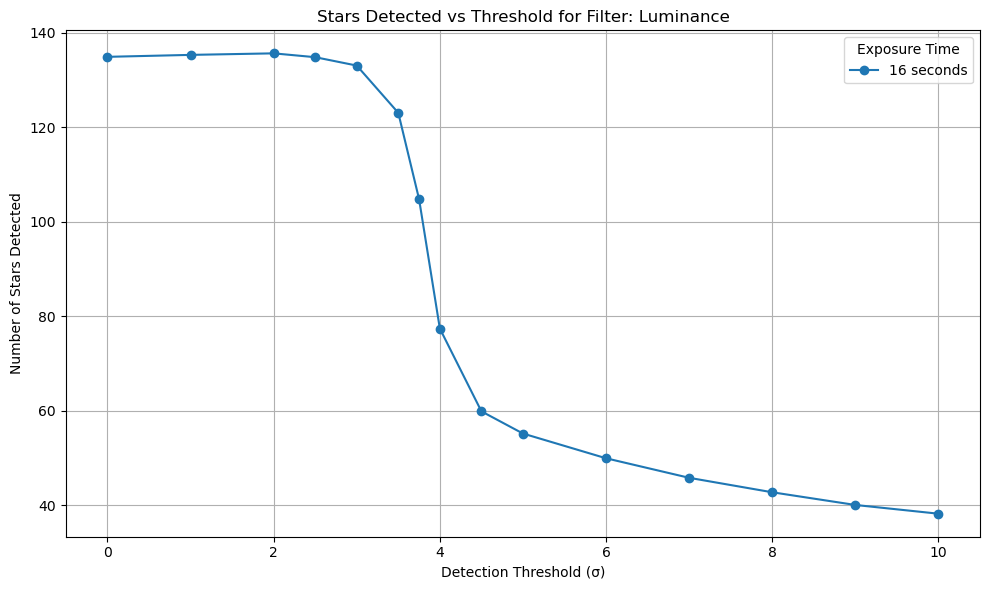

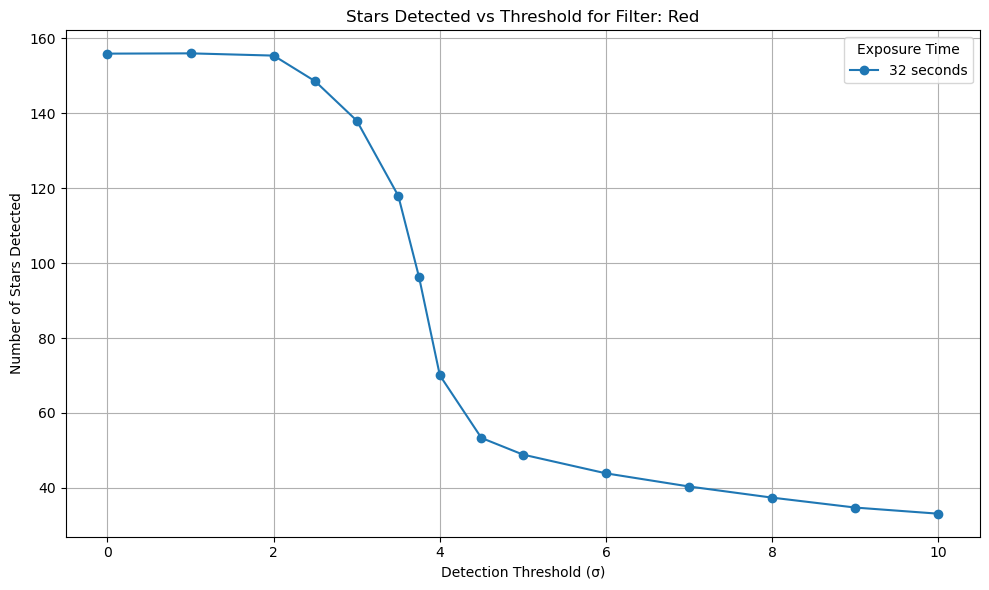

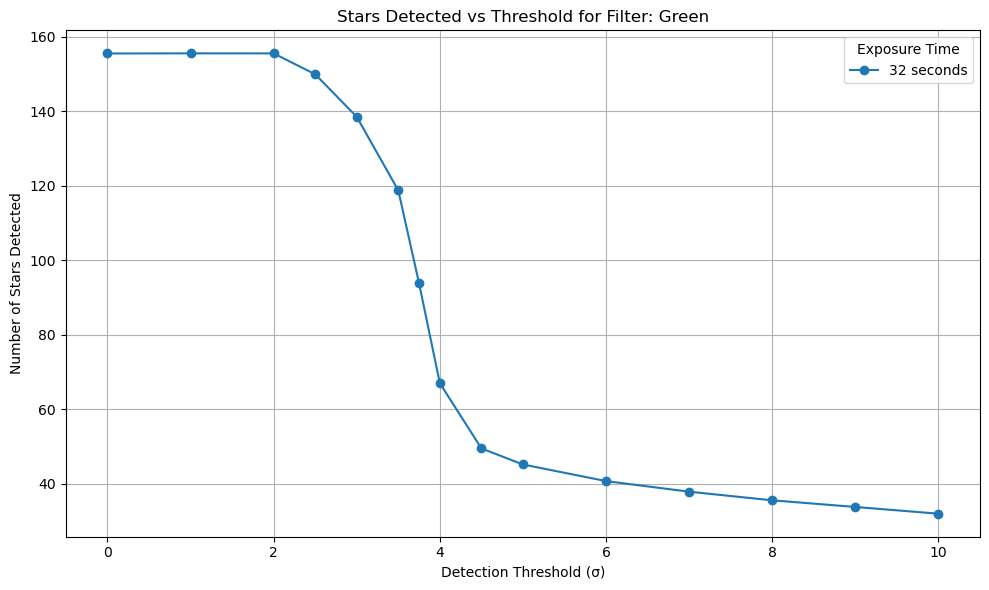

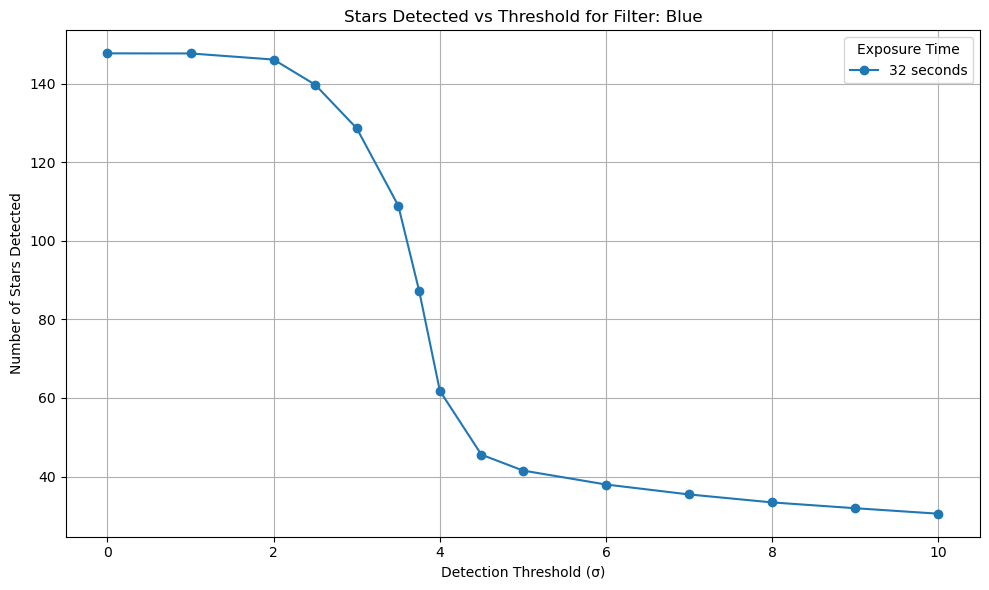

In [8]:
for selected_filter in colour_list:

    # Filter the DataFrame
    df_filtered = combined_df[combined_df["colour"] == selected_filter]
    
    # Group by exposure and threshold, then average
    df_avg = (
        df_filtered
        .groupby(["exposure_id", "threshold"], as_index=False)
        .agg({"number_of_stars": "mean"})
    )
    
    # Plot: one line per exposure time
    plt.figure(figsize=(10, 6))
    
    for exposure, group in df_avg.groupby("exposure_id"):
        sorted_group = group.sort_values("threshold")
        plt.plot(
            sorted_group["threshold"],
            sorted_group["number_of_stars"],
            marker="o",
            label=f"{exposure} seconds"
        )
    
    plt.title(f"Stars Detected vs Threshold for Filter: {selected_filter}")
    plt.xlabel("Detection Threshold (σ)")
    plt.ylabel("Number of Stars Detected")
    plt.legend(title="Exposure Time")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
